Citation: I used Claude (Anthropic's Claude Code, Opus 4.8) to help build and refine this notebook — drafting the analysis structure, code, and explanations. I reviewed, ran, and verified all code and interpretations myself.

In [ ]:
Author: Vihaan Manchanda

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the Dataset and Cleaning 

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observations:

1. customerID is just an ID, it won't help the model, so need to drop it
2. TotalCharges came in as text (object). Some rows are blank spaces, which happens for brand new customers with tenure = 0. Convert it to a number and drop those few empty rows
3. Churn is "Yes"/"No". Need to turn it into 0/1.

In [5]:
df = df.drop(columns=["customerID"])

# TotalCharges has some blank strings -> make them proper numbers (blanks become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges rows:", df["TotalCharges"].isna().sum())

df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Target: Yes/No -> 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Rows after cleaning:", df.shape[0])
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].describe()

Blank TotalCharges rows: 11
Rows after cleaning: 7032


,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785
std,24.545260,30.085974,2266.771362,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.862500,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [6]:
#EDA relevant to linear regression assumptions.

In [ ]:
# Distribution of numerical features - tenure and total_Charges. 

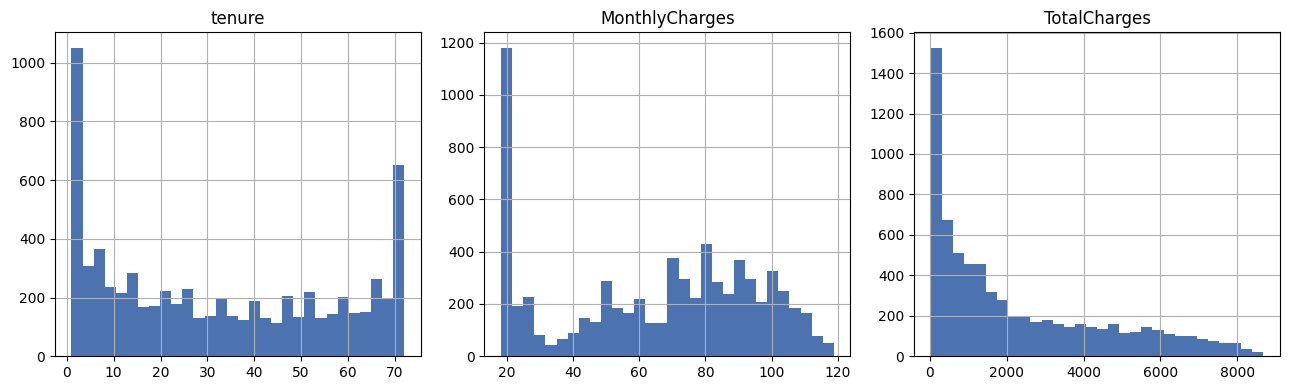

In [11]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].hist(bins=30, figsize=(13, 4), layout=(1, 3), color="#4c72b0")
plt.tight_layout()
plt.show()

Observation - Data seems pretty skewed, ie,  lots of new, low-spend customers.

In [ ]:
# Correlations  

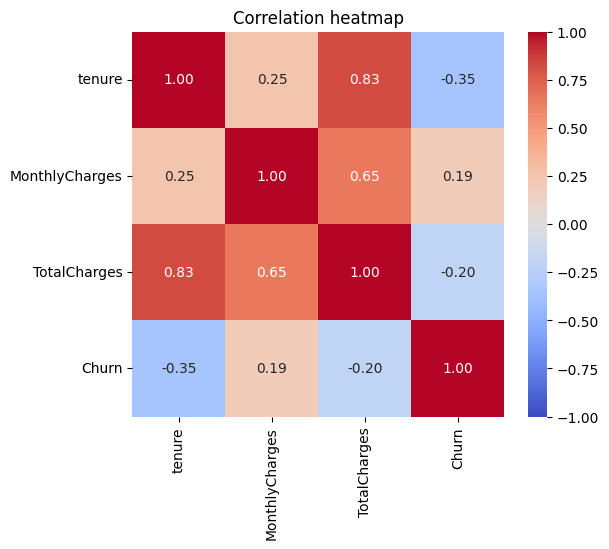

In [12]:
corr = df[num_cols + ["Churn"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

Observation: `tenure` and `TotalCharges` are strongly correlated with each other.

In [13]:
# Linearity check

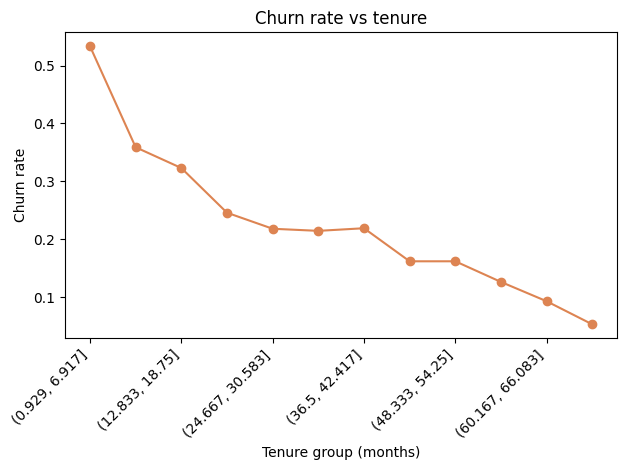

In [15]:
df.groupby(pd.cut(df["tenure"], 12), observed=True)["Churn"].mean().plot(
    marker="o", color="#dd8452")
plt.ylabel("Churn rate"); plt.xlabel("Tenure group (months)")
plt.title("Churn rate vs tenure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observation: churn rate falls steadily as tenure grows, which is close to the straight-line relationship linear regression assumes.

In [14]:
# Linear regression model code

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
        "Contract", "InternetService", "PaymentMethod"]],
    drop_first=True,
).astype(float)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Model trained on", len(X_train), "customers.")

Model trained on 5625 customers.


In [8]:
# Model performance evidence

R^2      : 0.244
RMSE     : 0.384
Accuracy : 78.3%   (rounded at 0.5)


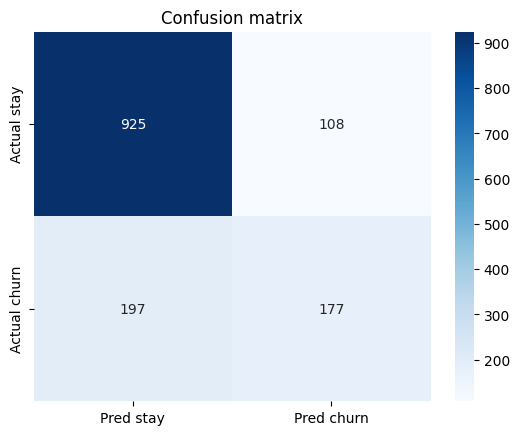

In [17]:
from sklearn.metrics import (r2_score, mean_squared_error,
                             accuracy_score, confusion_matrix)

print(f"R^2      : {r2_score(y_test, pred):.3f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred)):.3f}")
print(f"Accuracy : {accuracy_score(y_test, pred > 0.5):.1%}   (rounded at 0.5)")

cm = confusion_matrix(y_test, pred > 0.5)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred stay", "Pred churn"],
            yticklabels=["Actual stay", "Actual churn"])
plt.title("Confusion matrix")
plt.show()

In [9]:
# Coefficient interpretation in markdown.


In [18]:
pd.DataFrame({"feature": X.columns, "coefficient": model.coef_}
             ).sort_values("coefficient").reset_index(drop=True)

,feature,coefficient
0,Contract_One year,-0.136357
1,Contract_Two year,-0.103759
2,InternetService_No,-0.074467
3,PaymentMethod_Mailed check,-0.016949
4,PaymentMethod_Credit card (automatic),-0.010792
5,tenure,-0.001511
6,TotalCharges,-0.000050
7,MonthlyCharges,0.001926
8,SeniorCitizen,0.075761
9,PaymentMethod_Electronic check,0.081270


A coefficient tells us which way a feature pushes churn and how hard. A positive number means that feature makes churn more likely; a negative number means it makes churn less likely. One thing to keep in mind: the features are measured in different units (tenure in months, charges in dollars, and the rest are simple yes/no 0-or-1 columns), so we shouldn't compare the raw numbers head-to-head - the yes/no columns will always look bigger just because of how they're scaled.

- Customers with fiber optic internet are the most likely to churn — this feature has the strongest push toward leaving.
- Customers on a one-year or two-year contract are much less likely to churn than month-to-month customers, since a longer commitment keeps people around.
- Tenure has a small-looking number, but that's the effect of a single month; added up over the full ~72 months it becomes a large negative, so customers who've stayed longer are clearly less likely to leave.
- A higher monthly bill nudges churn up, while a higher total amount paid nudges it slightly down (which fits, since big totals usually mean long-staying customers).

Overall the model tells us: new customers, month-to-month plans, and fiber service are the warning signs for churn, while long tenure and long contracts point to customers who stay

In [10]:
# At least one limitation of using linear regression for churn.

Linear regression was built to predict numbers that can be anything — like a price or a temperature — where any value on the number line makes sense. But churn isn't an open-ended number; it's a yes/no outcome, which really means we want a probability between 0% and 100%. That mismatch causes a few problems:

The predictions don't stay between 0 and 1. Since the model can output any number, some customers get a predicted churn "score" below 0 (206 of them here) — and it can go above 1 too. A probability can't be negative or over 100%, so those values don't actually mean anything.
A straight line is the wrong shape for a yes/no answer. Linear regression draws a straight line through the data, but the real jump from "stays" to "leaves" is more of an S-shaped curve, so the straight line never fits it well.

The better tool is logistic regression. It's the same idea — combine the features to predict churn — but it bends the output into an S-curve that always stays between 0 and 1, so every prediction reads as a proper probability.